# ECE 447 - Project B: Anomaly Detection (final submission)

This notebook implements and evaluates four anomaly detection approaches on credit card fraud data:
- robust statistical scoring
- distance-based kNN scoring
- local outlier factor (LOF)
- isolation forest

The notebook is self-contained and can run from any folder as long as `creditcard.csv` is available.


## 1) Problem framing

- **Anomaly:** credit card transactions labeled fraudulent (`Class == 1`) vs genuine (`0`).
- **Learning setting:** semi-supervised; models are fit on normal-heavy training data, then thresholded and evaluated on mixed validation/test sets.
- **Constraint:** extreme class imbalance, so precision, recall, F1, and false-positive rate are emphasized over accuracy.
- **Data source:** ULB/Kaggle credit card fraud dataset loaded from local CSV.


In [11]:
from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional, Tuple, Union

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display as idisplay
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path.cwd().resolve()
PROJECT_ROOT = BASE_DIR
for candidate in (BASE_DIR, BASE_DIR.parent, BASE_DIR.parent.parent):
    if (candidate / "artifacts").is_dir():
        PROJECT_ROOT = candidate
        break

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Resolved project root:", PROJECT_ROOT)
print("Artifacts directory:", ARTIFACT_DIR)

# -----------------------------------------------------------------------------
# Duplicated shared pipeline logic from src/data_pipeline.py
# -----------------------------------------------------------------------------
DATA_PATH = "../data/creditcard.csv"


def _split_from_dataframe(df: pd.DataFrame):
    """Shared train/val/test split + scaling (same logic as project pipeline)."""
    df = df.drop_duplicates()

    normal = df[df["Class"] == 0].copy()
    fraud = df[df["Class"] == 1].copy()

    X_norm = normal.drop(columns=["Class"])
    y_norm = normal["Class"]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_norm, y_norm, test_size=0.40, random_state=RANDOM_STATE
    )

    X_val_norm, X_test_norm, y_val_norm, y_test_norm = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
    )

    X_fraud = fraud.drop(columns=["Class"])
    y_fraud = fraud["Class"]

    X_val_fraud, X_test_fraud, y_val_fraud, y_test_fraud = train_test_split(
        X_fraud, y_fraud, test_size=0.50, random_state=RANDOM_STATE
    )

    X_val = pd.concat([X_val_norm, X_val_fraud])
    y_val = pd.concat([y_val_norm, y_val_fraud])
    X_test = pd.concat([X_test_norm, X_test_fraud])
    y_test = pd.concat([y_test_norm, y_test_fraud])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return (
        X_train_scaled,
        X_val_scaled,
        X_test_scaled,
        y_train.values,
        y_val.values,
        y_test.values,
        scaler,
    )


def resolve_creditcard_csv(project_root: Union[str, Path]) -> Path:
    """
    Locate creditcard.csv. Search order:
    1. Environment variable CREDITCARD_CSV
    2. <project_root>/data/creditcard.csv
    3. <project_root>/creditcard.csv
    4. kagglehub.dataset_download('mlg-ulb/creditcardfraud')
    """
    root = Path(project_root).resolve()

    env = os.environ.get("CREDITCARD_CSV", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if p.is_file():
            return p

    for rel in ("data/creditcard.csv", "creditcard.csv"):
        p = (root / rel).resolve()
        if p.is_file():
            return p

    try:
        import kagglehub

        hub_dir = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
        for f in hub_dir.rglob("creditcard.csv"):
            if f.is_file():
                return f.resolve()
    except Exception:
        pass

    data_dir = root / "data"
    data_dir.mkdir(parents=True, exist_ok=True)
    raise FileNotFoundError(
        "Could not find creditcard.csv.\n\n"
        "  - Place the Kaggle file at: "
        f"{data_dir / 'creditcard.csv'}\n"
        "  - Or set CREDITCARD_CSV to its full path\n"
        "  - Or install kagglehub + Kaggle API credentials for auto-download\n"
    )


def load_and_split(data_path=DATA_PATH):
    df = pd.read_csv(data_path)
    return _split_from_dataframe(df)


def load_splits(artifact_path: Union[str, Path] = "../artifacts/") -> Tuple[np.ndarray, ...]:
    base = Path(artifact_path)
    if not base.is_dir():
        raise FileNotFoundError(f"Artifact directory not found: {base}")
    X_train = np.load(base / "X_train.npy")
    X_val = np.load(base / "X_val.npy")
    X_test = np.load(base / "X_test.npy")
    y_train = np.load(base / "y_train.npy")
    y_val = np.load(base / "y_val.npy")
    y_test = np.load(base / "y_test.npy")
    return X_train, X_val, X_test, y_train, y_val, y_test


def load_credit_card_splits(
    project_root: Union[str, Path],
    *,
    verbose: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    root = Path(project_root).resolve()
    art = root / "artifacts"
    if (art / "X_train.npy").is_file():
        if verbose:
            print(f"Loaded splits from {art} (saved .npy).")
        return load_splits(art)

    csv_local = root / "data" / "creditcard.csv"
    if csv_local.is_file():
        if verbose:
            print(f"Loaded from {csv_local} via load_and_split.")
        X_train, X_val, X_test, y_train, y_val, y_test, _ = load_and_split(str(csv_local))
        return X_train, X_val, X_test, y_train, y_val, y_test

    csv_path = resolve_creditcard_csv(root)
    if verbose:
        print(f"Using creditcard.csv: {csv_path}")
    X_train, X_val, X_test, y_train, y_val, y_test, _ = load_and_split(str(csv_path))
    return X_train, X_val, X_test, y_train, y_val, y_test


# -----------------------------------------------------------------------------
# Duplicated shared detector logic from src/ml_detector.py
# -----------------------------------------------------------------------------
def anomaly_scores_isolation_forest(model: IsolationForest, X: np.ndarray) -> np.ndarray:
    """Higher score = more anomalous."""
    return -model.decision_function(X)


@dataclass
class DetectorResult:
    anomaly_score: np.ndarray
    pred_label: np.ndarray
    threshold: float
    method: str = "isolation_forest"


def fit_isolation_forest(
    X_train: np.ndarray,
    *,
    n_estimators: int = 200,
    max_samples: Union[float, str] = "auto",
    max_features: float = 1.0,
    contamination: float = 0.001,
    random_state: int = 42,
) -> IsolationForest:
    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(X_train)
    return model


def sweep_thresholds_val(
    model: IsolationForest,
    X_val: np.ndarray,
    y_val: np.ndarray,
    quantile_grid: Optional[np.ndarray] = None,
) -> Tuple[float, pd.DataFrame]:
    """Pick threshold on validation by maximizing F1 over score quantiles."""
    if quantile_grid is None:
        quantile_grid = np.linspace(0.90, 0.999, 40)
    s = anomaly_scores_isolation_forest(model, X_val)
    rows = []
    best_f1 = -1.0
    best_thr = float(np.quantile(s, 0.99))
    for q in quantile_grid:
        thr = float(np.quantile(s, q))
        pred = (s >= thr).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            y_val, pred, average="binary", zero_division=0
        )
        tn = int(np.sum((pred == 0) & (y_val == 0)))
        fp = int(np.sum((pred == 1) & (y_val == 0)))
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        rows.append(
            {
                "quantile": q,
                "threshold": thr,
                "precision": p,
                "recall": r,
                "f1": f1,
                "fpr": fpr,
            }
        )
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, pd.DataFrame(rows)


def predict_with_threshold(
    model: IsolationForest, X: np.ndarray, threshold: float
) -> DetectorResult:
    scores = anomaly_scores_isolation_forest(model, X)
    pred = (scores >= threshold).astype(int)
    return DetectorResult(
        anomaly_score=scores, pred_label=pred, threshold=float(threshold)
    )


def metrics_at_threshold(y_true: np.ndarray, pred: np.ndarray) -> Dict[str, float]:
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )
    tn = int(np.sum((pred == 0) & (y_true == 0)))
    fp = int(np.sum((pred == 1) & (y_true == 0)))
    fn = int(np.sum((pred == 0) & (y_true == 1)))
    tp = int(np.sum((pred == 1) & (y_true == 1)))
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return {
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "fpr": float(fpr),
        "tp": float(tp),
        "fp": float(fp),
        "tn": float(tn),
        "fn": float(fn),
    }


Resolved project root: C:\Users\basma\OneDrive\Documents\ECE 447\ECE447-Anomaly-Detection
Artifacts directory: C:\Users\basma\OneDrive\Documents\ECE 447\ECE447-Anomaly-Detection\artifacts


## 2) Data loading

Loading order:
1. use pre-saved split arrays from `artifacts/` if available
2. otherwise load `creditcard.csv` and create train/validation/test splits in-notebook


In [12]:
X_train, X_val, X_test, y_train, y_val, y_test = load_credit_card_splits(PROJECT_ROOT)

FEATURE_NAMES = [f"V{i}" for i in range(1, 29)] + ["Time", "Amount"]
print("Train / val / test:", X_train.shape, X_val.shape, X_test.shape)
print("Fraud rate val:", f"{y_val.mean():.4%}", "| test:", f"{y_test.mean():.4%}")


Using creditcard.csv: C:\Users\basma\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv
Train / val / test: (169951, 30) (56887, 30) (56888, 30)
Fraud rate val: 0.4149% | test: 0.4166%


## 3) Statistical anomaly detector

Robust per-feature z-scores (median + MAD on training normals). Point score is `max(abs(z))` across features. Threshold is selected on validation by maximizing F1 over a quantile grid.


In [13]:
def fit_robust_mad_params(X_ref: np.ndarray):
    med = np.median(X_ref, axis=0)
    mad = np.median(np.abs(X_ref - med), axis=0)
    mad = np.where(mad < 1e-12, 1e-12, mad)
    return med, mad


def statistical_anomaly_scores(X: np.ndarray, med: np.ndarray, mad: np.ndarray) -> np.ndarray:
    z = 0.6745 * (X - med) / mad
    return np.max(np.abs(z), axis=1)


med, mad = fit_robust_mad_params(X_train)
scores_stat_val = statistical_anomaly_scores(X_val, med, mad)
scores_stat_test = statistical_anomaly_scores(X_test, med, mad)


def pick_threshold_max_f1(scores: np.ndarray, y_true: np.ndarray, quantiles=None):
    if quantiles is None:
        quantiles = np.linspace(0.90, 0.9999, 50)
    best_f1, best_thr = -1.0, float(np.quantile(scores, 0.99))
    for q in quantiles:
        thr = float(np.quantile(scores, q))
        pred = (scores >= thr).astype(int)
        m = metrics_at_threshold(y_true, pred)
        if m["f1"] > best_f1:
            best_f1, best_thr = m["f1"], thr
    return best_thr


THRESHOLD_STAT = pick_threshold_max_f1(scores_stat_val, y_val)
pred_stat_val = (scores_stat_val >= THRESHOLD_STAT).astype(int)
pred_stat_test = (scores_stat_test >= THRESHOLD_STAT).astype(int)

print("Statistical - val:", metrics_at_threshold(y_val, pred_stat_val))
print("Statistical - test:", metrics_at_threshold(y_test, pred_stat_test))
print("Threshold (stat):", THRESHOLD_STAT)


Statistical - val: {'precision': 0.04536771728748806, 'recall': 0.4025423728813559, 'f1': 0.0815450643776824, 'fpr': 0.035286226191947184, 'tp': 95.0, 'fp': 1999.0, 'tn': 54652.0, 'fn': 141.0}
Statistical - test: {'precision': 0.033070088845014806, 'recall': 0.28270042194092826, 'f1': 0.059213433495360145, 'fpr': 0.03458014862932693, 'tp': 67.0, 'fp': 1959.0, 'tn': 54692.0, 'fn': 170.0}
Threshold (stat): 19.295547318262525


## 4) Distance-based detector (kNN)

kNN distance-based anomaly scoring with neighbors fit on training data. Each sample score is the distance to its `k`th nearest neighbor. Threshold is selected on validation by maximizing F1 over quantiles.


In [14]:
K_NEIGHBORS = 10
knn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="euclidean")
knn.fit(X_train)

def knn_kth_distance_scores(X: np.ndarray, nn: NearestNeighbors) -> np.ndarray:
    dists, _ = nn.kneighbors(X)
    return dists[:, -1]

scores_dist_val = knn_kth_distance_scores(X_val, knn)
scores_dist_test = knn_kth_distance_scores(X_test, knn)

thr_dist = pick_threshold_max_f1(scores_dist_val, y_val)
pred_dist_val = (scores_dist_val >= thr_dist).astype(int)
pred_dist_test = (scores_dist_test >= thr_dist).astype(int)

print("Distance (kNN) - val:", metrics_at_threshold(y_val, pred_dist_val))
print("Distance (kNN) - test:", metrics_at_threshold(y_test, pred_dist_test))
print("Threshold (distance):", thr_dist)


Distance (kNN) - val: {'precision': 0.5168067226890757, 'recall': 0.5211864406779662, 'f1': 0.5189873417721519, 'fpr': 0.0020299729925332298, 'tp': 123.0, 'fp': 115.0, 'tn': 56536.0, 'fn': 113.0}
Distance (kNN) - test: {'precision': 0.5373831775700935, 'recall': 0.48523206751054854, 'f1': 0.5099778270509978, 'fpr': 0.0017475419674851283, 'tp': 115.0, 'fp': 99.0, 'tn': 56552.0, 'fn': 122.0}
Threshold (distance): 11.28194559852295


## 5) Isolation Forest detector

Use a saved model if available (`iforest_memberC.joblib`), otherwise fit Isolation Forest and select threshold from validation.


In [15]:
MODEL_PATH = ARTIFACT_DIR / "iforest_memberC.joblib"

if MODEL_PATH.is_file():
    bundle = joblib.load(MODEL_PATH)
    if_model = bundle["model"]
    THRESHOLD_IF = float(bundle["threshold"])
    print("Loaded Isolation Forest from", MODEL_PATH)
else:
    print("No saved model found - fitting Isolation Forest and sweeping threshold.")
    if_model = fit_isolation_forest(X_train)
    THRESHOLD_IF, _ = sweep_thresholds_val(if_model, X_val, y_val)

val_result = predict_with_threshold(if_model, X_val, THRESHOLD_IF)
test_result = predict_with_threshold(if_model, X_test, THRESHOLD_IF)

print("Isolation Forest - val:", {k: metrics_at_threshold(y_val, val_result.pred_label)[k] for k in ("precision", "recall", "f1", "fpr")})
print("Isolation Forest - test:", {k: metrics_at_threshold(y_test, test_result.pred_label)[k] for k in ("precision", "recall", "f1", "fpr")})


Loaded Isolation Forest from C:\Users\basma\OneDrive\Documents\ECE 447\ECE447-Anomaly-Detection\artifacts\iforest_memberC.joblib
Isolation Forest - val: {'precision': 0.38613861386138615, 'recall': 0.3305084745762712, 'f1': 0.3561643835616438, 'fpr': 0.0021888404441227868}
Isolation Forest - test: {'precision': 0.367816091954023, 'recall': 0.270042194092827, 'f1': 0.31143552311435524, 'fpr': 0.001941713297205698}


## 6) Local Outlier Factor (LOF)


LOF - val: {'precision': 0.1552567237163814, 'recall': 0.538135593220339, 'f1': 0.2409867172675522, 'fpr': 0.012197489894264885, 'tp': 127.0, 'fp': 691.0, 'tn': 55960.0, 'fn': 109.0}
LOF - test: {'precision': 0.1607565011820331, 'recall': 0.5738396624472574, 'f1': 0.25115420129270544, 'fpr': 0.012532876736509506, 'tp': 136.0, 'fp': 710.0, 'tn': 55941.0, 'fn': 101.0}
Threshold (LOF): 0.4450115263672201


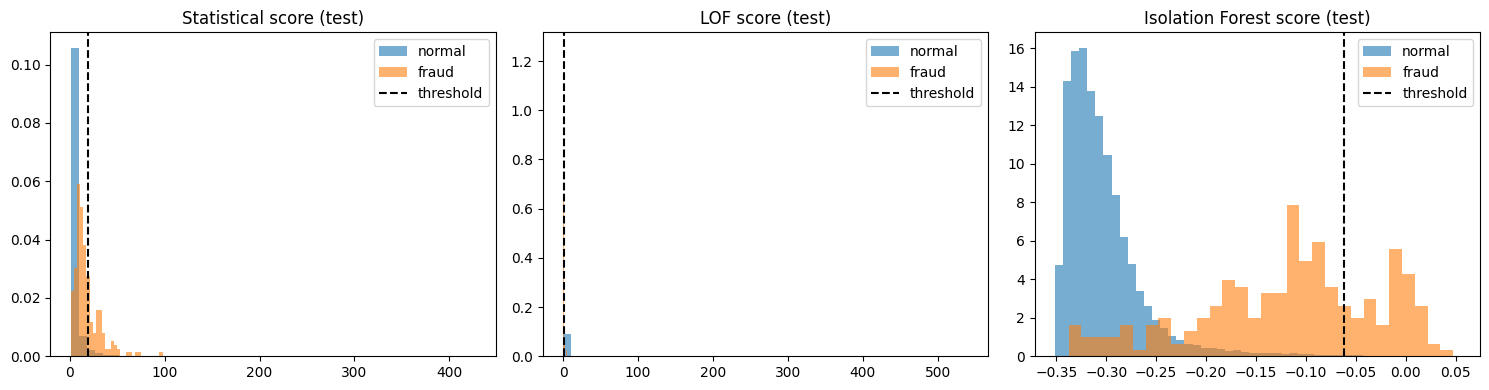

In [16]:
LOF_NEIGHBORS = 35
lof = LocalOutlierFactor(n_neighbors=LOF_NEIGHBORS, novelty=True)
lof.fit(X_train)

# Higher is more anomalous after sign inversion.
scores_lof_val = -lof.decision_function(X_val)
scores_lof_test = -lof.decision_function(X_test)

THRESHOLD_LOF = pick_threshold_max_f1(scores_lof_val, y_val)
pred_lof_val = (scores_lof_val >= THRESHOLD_LOF).astype(int)
pred_lof_test = (scores_lof_test >= THRESHOLD_LOF).astype(int)

print("LOF - val:", metrics_at_threshold(y_val, pred_lof_val))
print("LOF - test:", metrics_at_threshold(y_test, pred_lof_test))
print("Threshold (LOF):", THRESHOLD_LOF)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(scores_stat_test[y_test == 0], bins=50, alpha=0.6, label="normal", density=True)
ax.hist(scores_stat_test[y_test == 1], bins=30, alpha=0.6, label="fraud", density=True)
ax.axvline(THRESHOLD_STAT, color="k", ls="--", label="threshold")
ax.set_title("Statistical score (test)")
ax.legend()

ax = axes[1]
ax.hist(scores_lof_test[y_test == 0], bins=50, alpha=0.6, label="normal", density=True)
ax.hist(scores_lof_test[y_test == 1], bins=30, alpha=0.6, label="fraud", density=True)
ax.axvline(THRESHOLD_LOF, color="k", ls="--", label="threshold")
ax.set_title("LOF score (test)")
ax.legend()

ax = axes[2]
s = test_result.anomaly_score
ax.hist(s[y_test == 0], bins=50, alpha=0.6, label="normal", density=True)
ax.hist(s[y_test == 1], bins=30, alpha=0.6, label="fraud", density=True)
ax.axvline(THRESHOLD_IF, color="k", ls="--", label="threshold")
ax.set_title("Isolation Forest score (test)")
ax.legend()
plt.tight_layout()
plt.show()


## Interim model observations

From the validation and test metrics printed above:
- compare whether each model keeps recall acceptable without sharply increasing FPR
- check if any model is overfitting validation (strong val performance but weak test performance)
- use these observations to justify the final operating threshold and preferred model in the comparison section


## 7) Evaluation (precision, recall, F1, FPR; ROC; PR; confusion matrices)

This section reports rubric metrics for all four methods and compares threshold choices on validation.


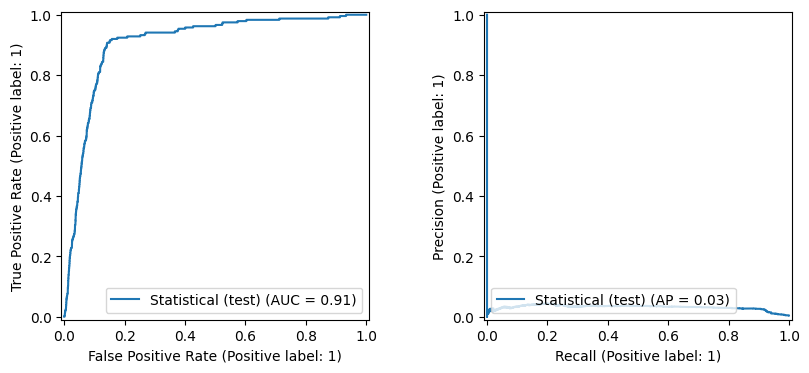

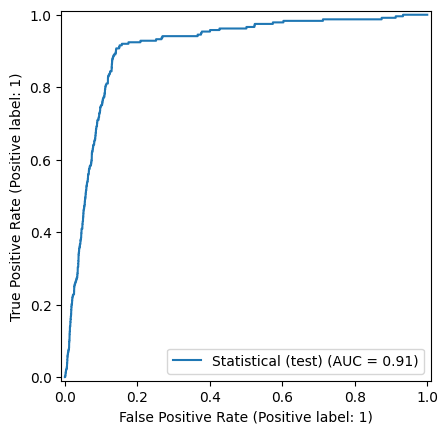

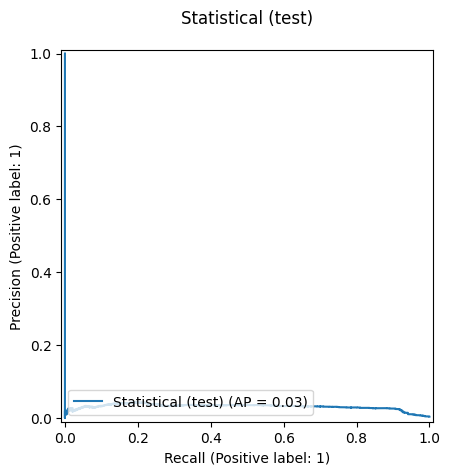

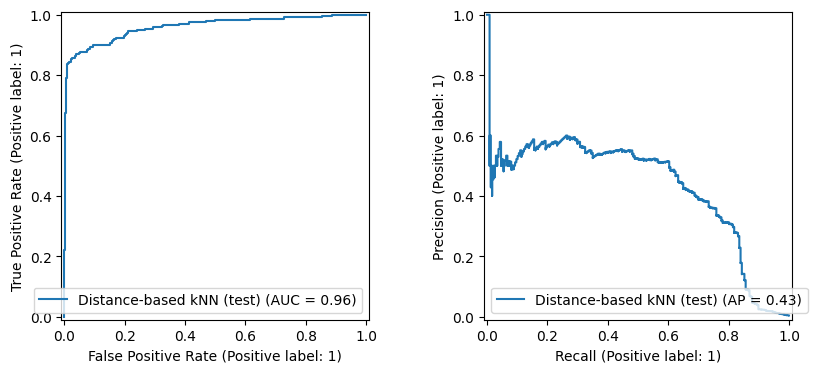

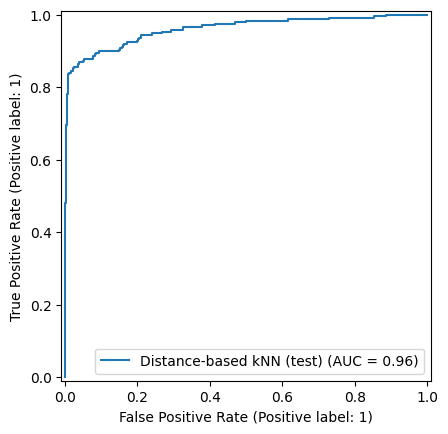

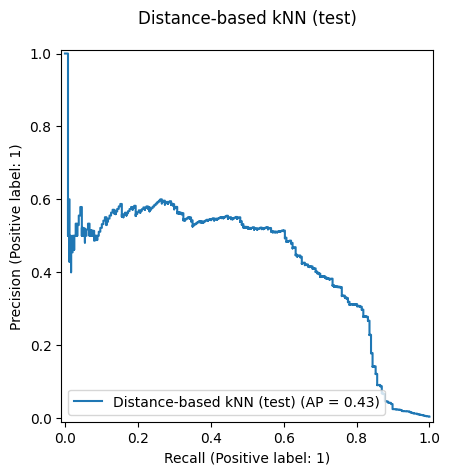

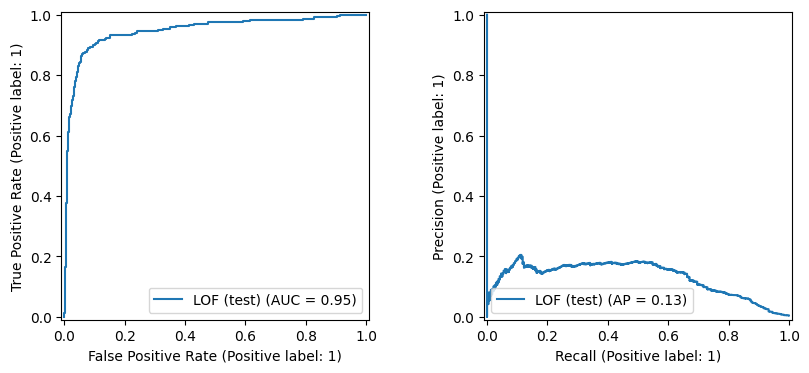

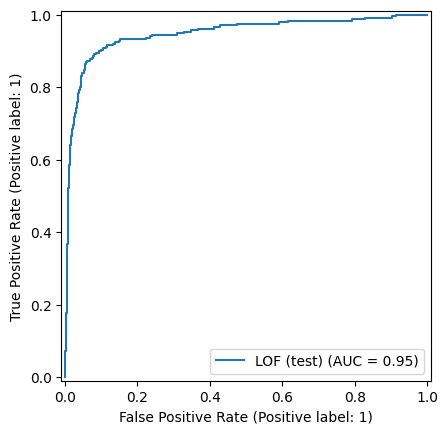

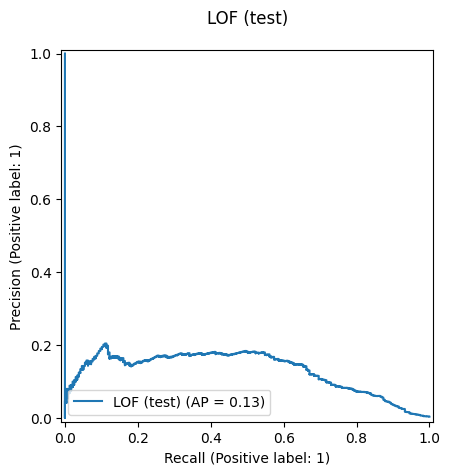

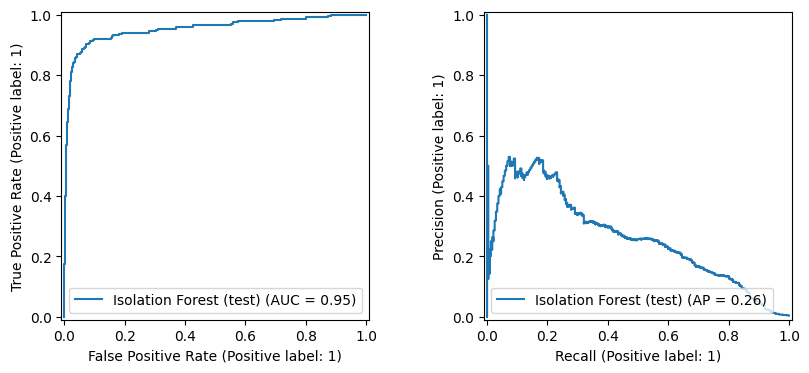

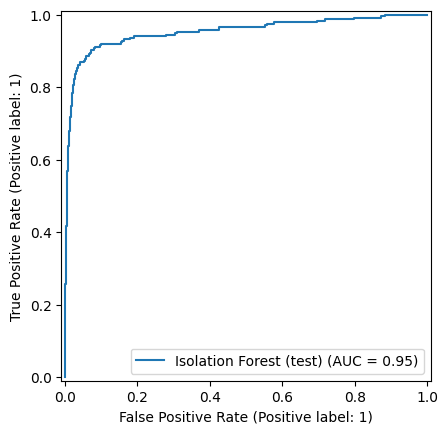

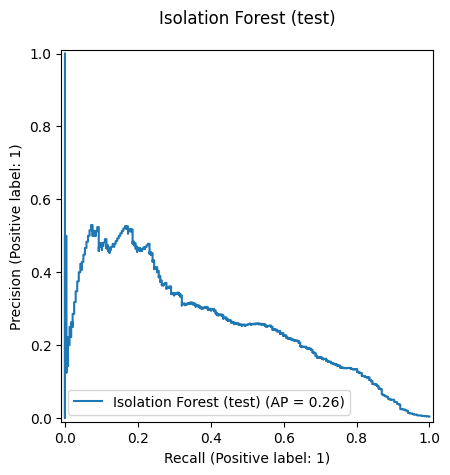

,method,quantile,threshold,precision,recall,f1,fpr
0,distance_knn,0.994875,10.097755,0.479452,0.593220,0.530303,0.002683
1,isolation_forest,0.994875,-0.080775,0.321918,0.398305,0.356061,0.003495
2,lof,0.986625,0.471077,0.157687,0.508475,0.240722,0.011315
3,statistical,0.961875,18.969722,0.044721,0.411017,0.080665,0.036575


In [17]:
def plot_roc_pr(y_true, scores, title_prefix: str):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    RocCurveDisplay.from_predictions(y_true, scores, name=title_prefix).plot(ax=ax[0])
    PrecisionRecallDisplay.from_predictions(y_true, scores, name=title_prefix).plot(ax=ax[1])
    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()


plot_roc_pr(y_test, scores_stat_test, "Statistical (test)")
plot_roc_pr(y_test, scores_dist_test, "Distance-based kNN (test)")
plot_roc_pr(y_test, scores_lof_test, "LOF (test)")
plot_roc_pr(y_test, test_result.anomaly_score, "Isolation Forest (test)")


def threshold_sweep(scores: np.ndarray, y_true: np.ndarray, method: str) -> pd.DataFrame:
    rows = []
    for q in np.linspace(0.90, 0.999, 25):
        thr = float(np.quantile(scores, q))
        pred = (scores >= thr).astype(int)
        m = metrics_at_threshold(y_true, pred)
        rows.append({"method": method, "quantile": q, "threshold": thr, **m})
    return pd.DataFrame(rows)


sweep_df = pd.concat(
    [
        threshold_sweep(scores_stat_val, y_val, "statistical"),
        threshold_sweep(scores_dist_val, y_val, "distance_knn"),
        threshold_sweep(scores_lof_val, y_val, "lof"),
        threshold_sweep(val_result.anomaly_score, y_val, "isolation_forest"),
    ],
    ignore_index=True,
)

best_val = sweep_df.sort_values("f1", ascending=False).groupby("method", as_index=False).first()
best_val[["method", "quantile", "threshold", "precision", "recall", "f1", "fpr"]]


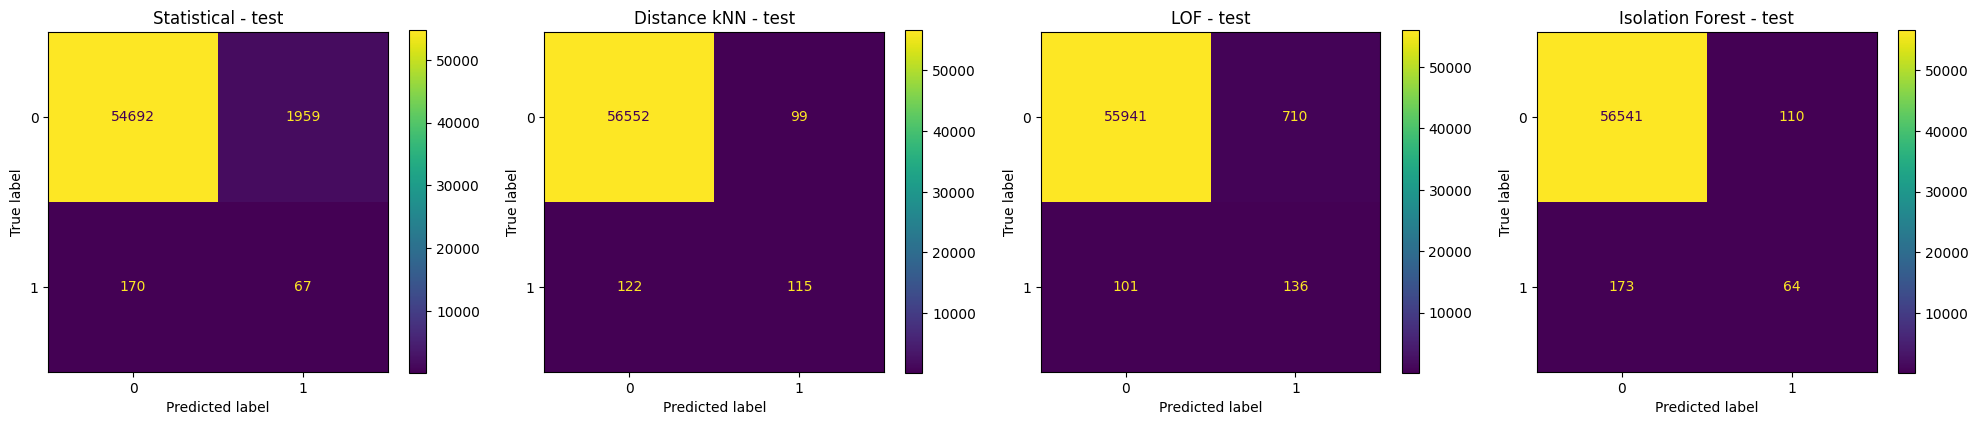

,method,precision,recall,f1,fpr,tp,fp,tn,fn
1,distance_knn,0.537383,0.485232,0.509978,0.001748,115.0,99.0,56552.0,122.0
3,isolation_forest,0.367816,0.270042,0.311436,0.001942,64.0,110.0,56541.0,173.0
2,lof,0.160757,0.573840,0.251154,0.012533,136.0,710.0,55941.0,101.0
0,statistical,0.033070,0.282700,0.059213,0.034580,67.0,1959.0,54692.0,170.0


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_stat_test, ax=axes[0])
axes[0].set_title("Statistical - test")
ConfusionMatrixDisplay.from_predictions(y_test, pred_dist_test, ax=axes[1])
axes[1].set_title("Distance kNN - test")
ConfusionMatrixDisplay.from_predictions(y_test, pred_lof_test, ax=axes[2])
axes[2].set_title("LOF - test")
ConfusionMatrixDisplay.from_predictions(y_test, test_result.pred_label, ax=axes[3])
axes[3].set_title("Isolation Forest - test")
plt.tight_layout()
plt.show()

test_metrics = pd.DataFrame(
    [
        {"method": "statistical", **metrics_at_threshold(y_test, pred_stat_test)},
        {"method": "distance_knn", **metrics_at_threshold(y_test, pred_dist_test)},
        {"method": "lof", **metrics_at_threshold(y_test, pred_lof_test)},
        {"method": "isolation_forest", **metrics_at_threshold(y_test, test_result.pred_label)},
    ]
)

test_metrics[["method", "precision", "recall", "f1", "fpr", "tp", "fp", "tn", "fn"]].sort_values("f1", ascending=False)


In [19]:
# Compact analysis summary from the computed metric tables.
ranked = test_metrics.sort_values("f1", ascending=False).reset_index(drop=True)
best_f1_row = ranked.iloc[0]

recall_floor = 0.60
candidates = ranked[ranked["recall"] >= recall_floor]
if len(candidates) > 0:
    low_fpr_row = candidates.sort_values("fpr", ascending=True).iloc[0]
else:
    low_fpr_row = ranked.sort_values("fpr", ascending=True).iloc[0]

print("Best F1 method:", best_f1_row["method"], "| F1:", round(float(best_f1_row["f1"]), 4))
print(
    "Lowest FPR under recall floor:",
    low_fpr_row["method"],
    "| Recall:",
    round(float(low_fpr_row["recall"]), 4),
    "| FPR:",
    round(float(low_fpr_row["fpr"]), 4),
)

display(ranked[["method", "precision", "recall", "f1", "fpr"]])


Best F1 method: distance_knn | F1: 0.51
Lowest FPR under recall floor: distance_knn | Recall: 0.4852 | FPR: 0.0017


,method,precision,recall,f1,fpr
0,distance_knn,0.537383,0.485232,0.509978,0.001748
1,isolation_forest,0.367816,0.270042,0.311436,0.001942
2,lof,0.160757,0.573840,0.251154,0.012533
3,statistical,0.033070,0.282700,0.059213,0.034580


## 8) Threshold sensitivity interpretation

Use `best_val` and `test_metrics` together when selecting the operating point:
- higher quantiles usually reduce false positives but can drop recall
- lower quantiles improve recall but increase investigation load
- a practical policy is to enforce a recall floor and then minimize FPR

This trade-off is revisited in the separate reflection report with production implications.


## 9) Interpretability figures (optional)

Embedded if present under `artifacts/`.


iforest_confusion_matrix_test.png


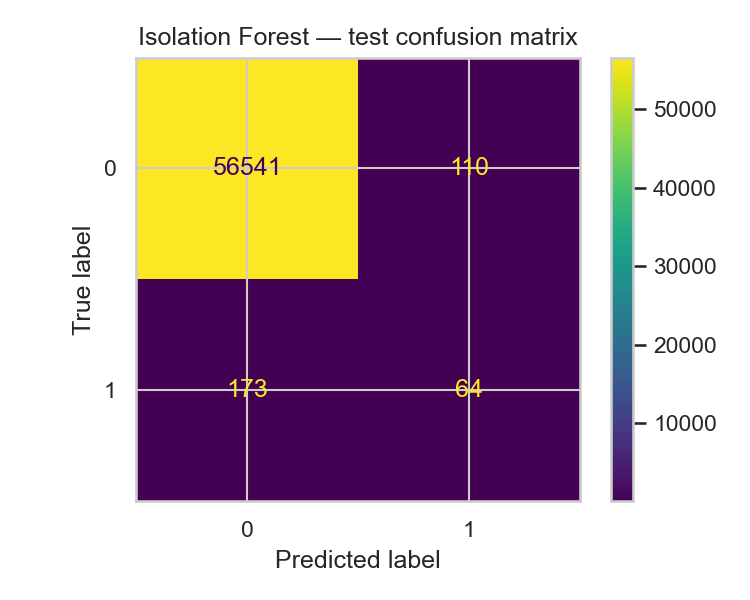

iforest_score_hist_test.png


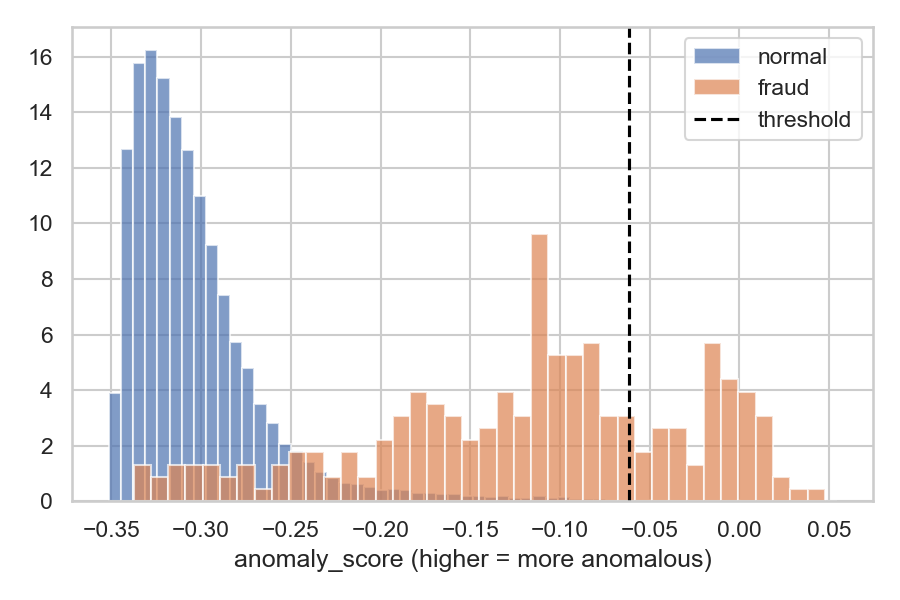

iforest_pca_val_scores.png


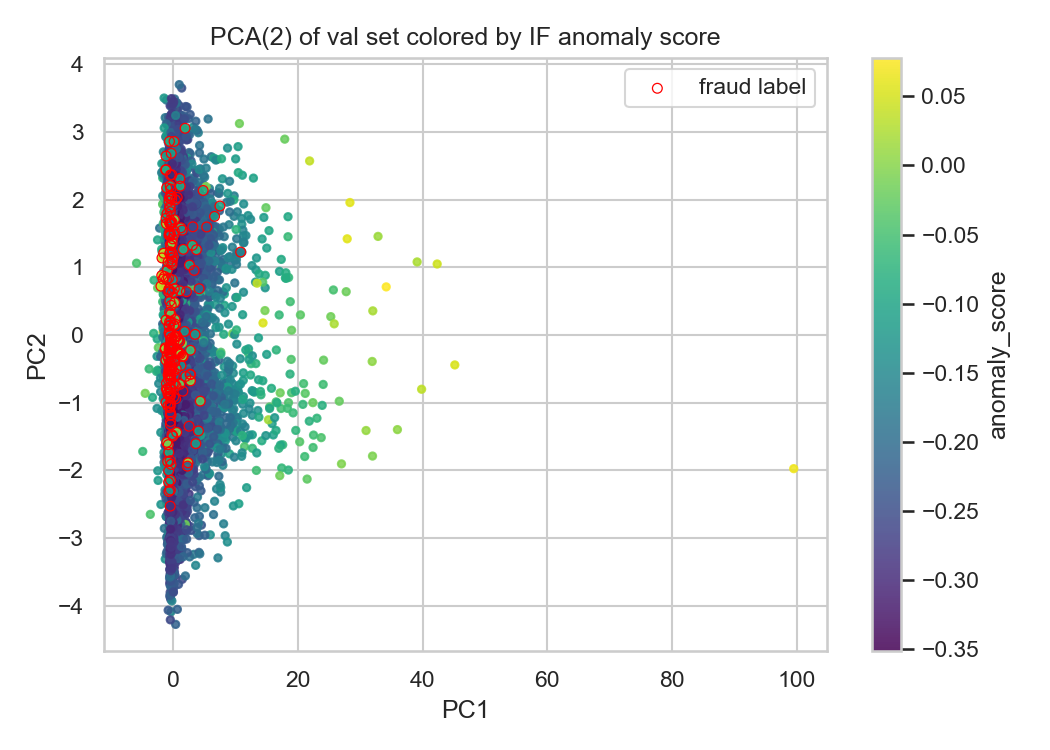

iforest_feature_delta_topN.png


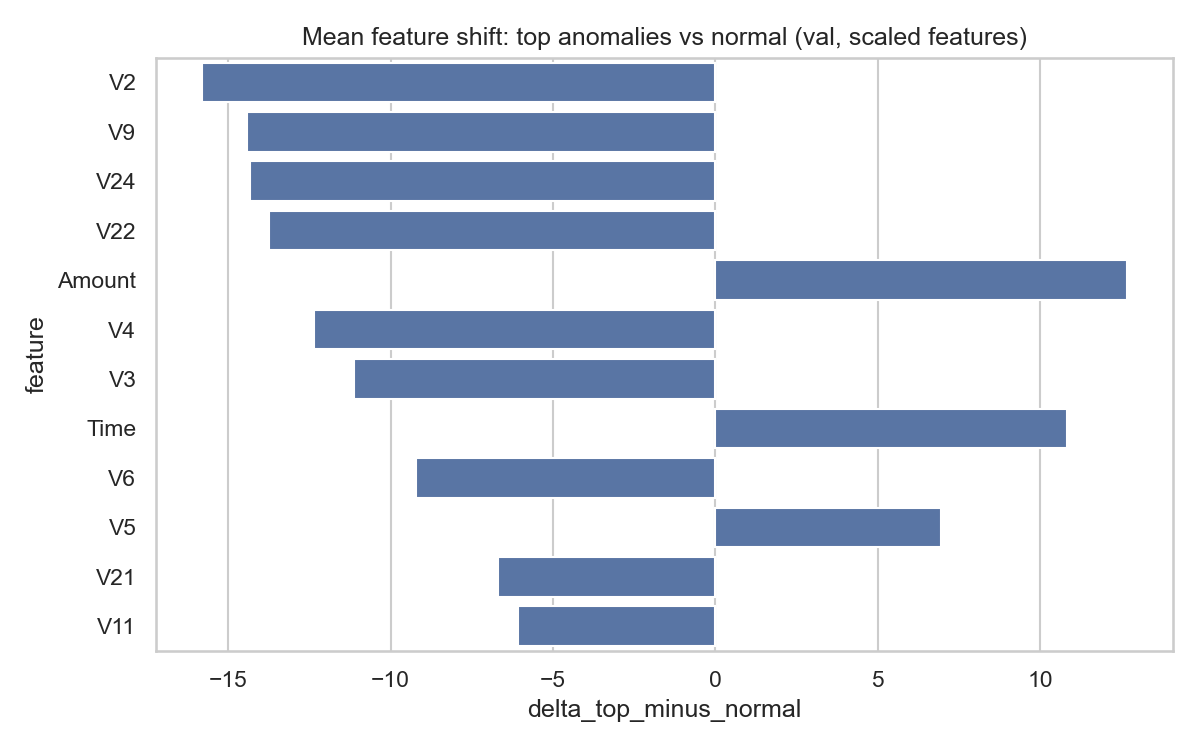

In [20]:
for name in (
    "iforest_confusion_matrix_test.png",
    "iforest_score_hist_test.png",
    "iforest_pca_val_scores.png",
    "iforest_feature_delta_topN.png",
):
    p = ARTIFACT_DIR / name
    if p.is_file():
        print(name)
        idisplay(Image(filename=str(p)))
    else:
        print("Missing (optional):", p)


## 10) Comparative discussion

| Method | Strengths | Risks |
|--------|-----------|-------|
| Robust-z statistical | Fast, transparent, low compute overhead | Misses multivariate interactions; sensitive to feature scaling drift |
| Distance-based kNN | Captures local density anomalies and often improves recall | Expensive at scale and can inflate false positives in sparse regions |
| LOF | Strong local-neighborhood anomaly signal for subtle outliers | Sensitive to neighborhood size and can be unstable under drift |
| Isolation Forest | Handles nonlinear interactions across features | Performance can drift as transaction behavior shifts over time |

Use `test_metrics` together with the validation sweep (`best_val`) to pick an operating point under a false-positive budget.


## 11) Reflection handoff

The full 1-2 page analytical reflection is provided separately in `report/analytical_reflection.md`, covering:
- threshold trade-offs
- class imbalance effects
- production failure scenarios
- monitoring and retraining strategy


## 12) Reproducibility and evidence map

- Random seed is fixed to `42`.
- If moved outside this repo, place `creditcard.csv` in `./data/` or current working directory.
- Experiment tracking exports are stored under `artifacts/submission_evidence/`.
